In [2]:
import os

SCALE, INTERVAL = 0.11, 4

mypass = '/mnt/ssd_data/Sasaki/MTSingleBeads'
mypass = '/Volumes/My Passport/Sasaki/MTsingleBeads'

path0 = os.path.join(mypass,"20260121/beads_trans_crop_crop/beads_tracks.csv")
path1 = os.path.join(mypass,"20260121/exp_crop1/beads_tracks.csv")
path2 = os.path.join(mypass,"20260122/exp/beads_tracks.csv")
path3 = os.path.join(mypass,"20260122/exp001/beads_tracks.csv")
path4 = os.path.join(mypass,"20260122/exp002/beads_tracks.csv")

paths = [path0, path1, path2, path3, path4]

In [39]:
import pandas as pd

df = pd.read_csv(path3)

def calculate_skewness_over_lags(df, max_lag, scale = 0.11, interval = 1):
    results = []
    
    # 1. データのソート（粒子ごと・フレーム順）
    df = df.sort_values(['particle', 'frame'])
    
    for lag in range(1, max_lag + 1):
        # 粒子ごとに指定したラグでの変位を計算
        # diff(lag) は x[t+lag] - x[t] 相当の差分を計算
        dx_lag = df.groupby('particle')['x'].transform(lambda x: x.diff(periods=lag)) * scale
        dy_lag = df.groupby('particle')['y'].transform(lambda x: x.diff(periods=lag)) * scale
        
        # このラグにおける粒子ごとの歪度を計算
        # temp_df を作って計算するとスムーズです
        temp_df = pd.DataFrame({'particle': df['particle'], 'dx': dx_lag, 'dy': dy_lag})
        skew_per_particle = temp_df.groupby('particle').skew()
        
        # 粒子全体の平均（Time-Ensemble Average）を算出
        mean_skew = skew_per_particle.mean()
        
        results.append({
            'lag': lag * interval,
            'skew_x': mean_skew['dx'],
            'skew_y': mean_skew['dy']
        })
    
    return pd.DataFrame(results)

# --- 実行 ---
# 例：ラグ1から20まで計算
max_lag = 250
skew_df = calculate_skewness_over_lags(df, max_lag, SCALE, INTERVAL)

print(skew_df)

      lag    skew_x    skew_y
0       4  0.764176 -0.243707
1       8  0.920636 -0.491385
2      12  0.910640 -0.698304
3      16  0.904019 -0.857481
4      20  0.899411 -0.993781
..    ...       ...       ...
245   984  0.179741  0.096134
246   988  0.181804  0.084294
247   992  0.222552  0.077297
248   996  0.343037  0.077997
249  1000  0.343722  0.079839

[250 rows x 3 columns]


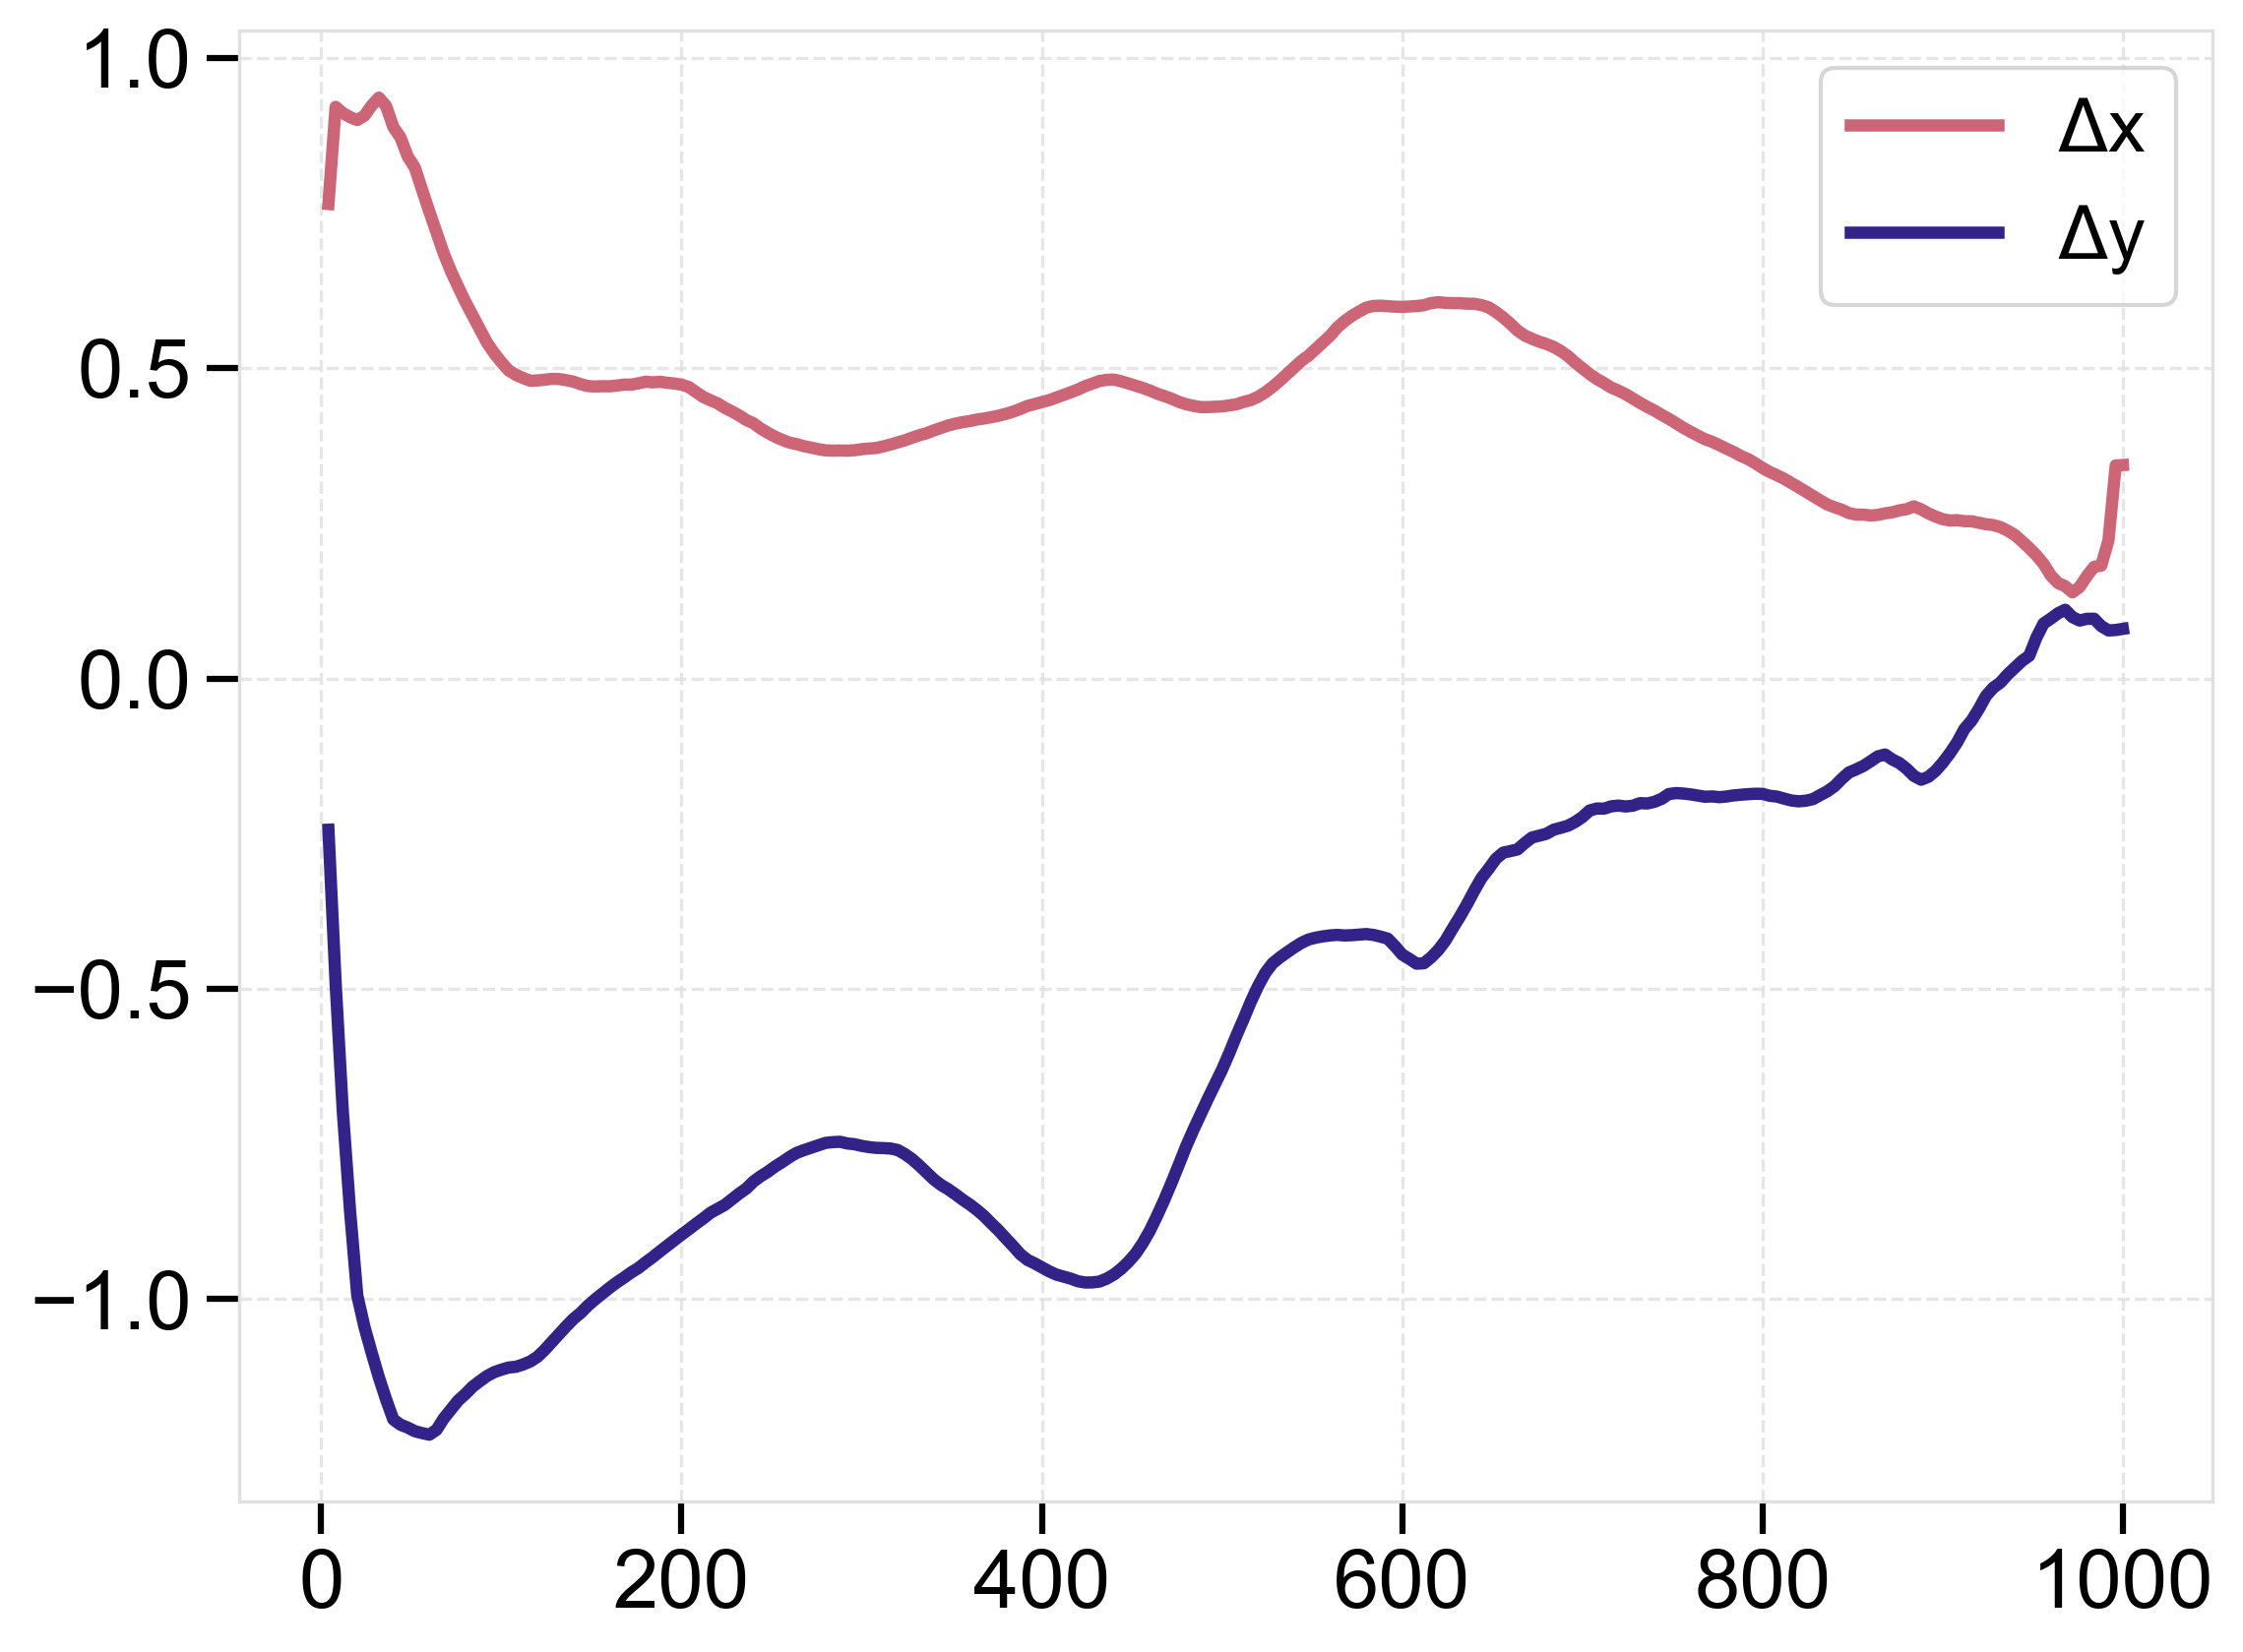

In [40]:
import matplotlib.pyplot as plt
plt.style.use('../libs/my_style.mplstyle')

fig, ax = plt.subplots()

ax.plot(skew_df['lag'], skew_df['skew_x'], label = "$\\Delta$x")
ax.plot(skew_df['lag'], skew_df['skew_y'], label = "$\\Delta$y")

ax.legend()

      lag  mrl_mean  mrl_exp_std  n_experiments  avg_intra_std
0       4  0.130932     0.111190              5       0.082057
1       8  0.178689     0.141948              5       0.113156
2      12  0.205144     0.157737              5       0.127025
3      16  0.225767     0.169258              5       0.142110
4      20  0.243276     0.176837              5       0.154107
..    ...       ...          ...            ...            ...
995  3984  0.999867          NaN              1       0.000184
996  3988  0.999923          NaN              1       0.000118
997  3992  0.999948          NaN              1       0.000051
998  3996  0.999890          NaN              1       0.000140
999  4000  0.999926          NaN              1       0.000133

[1000 rows x 5 columns]


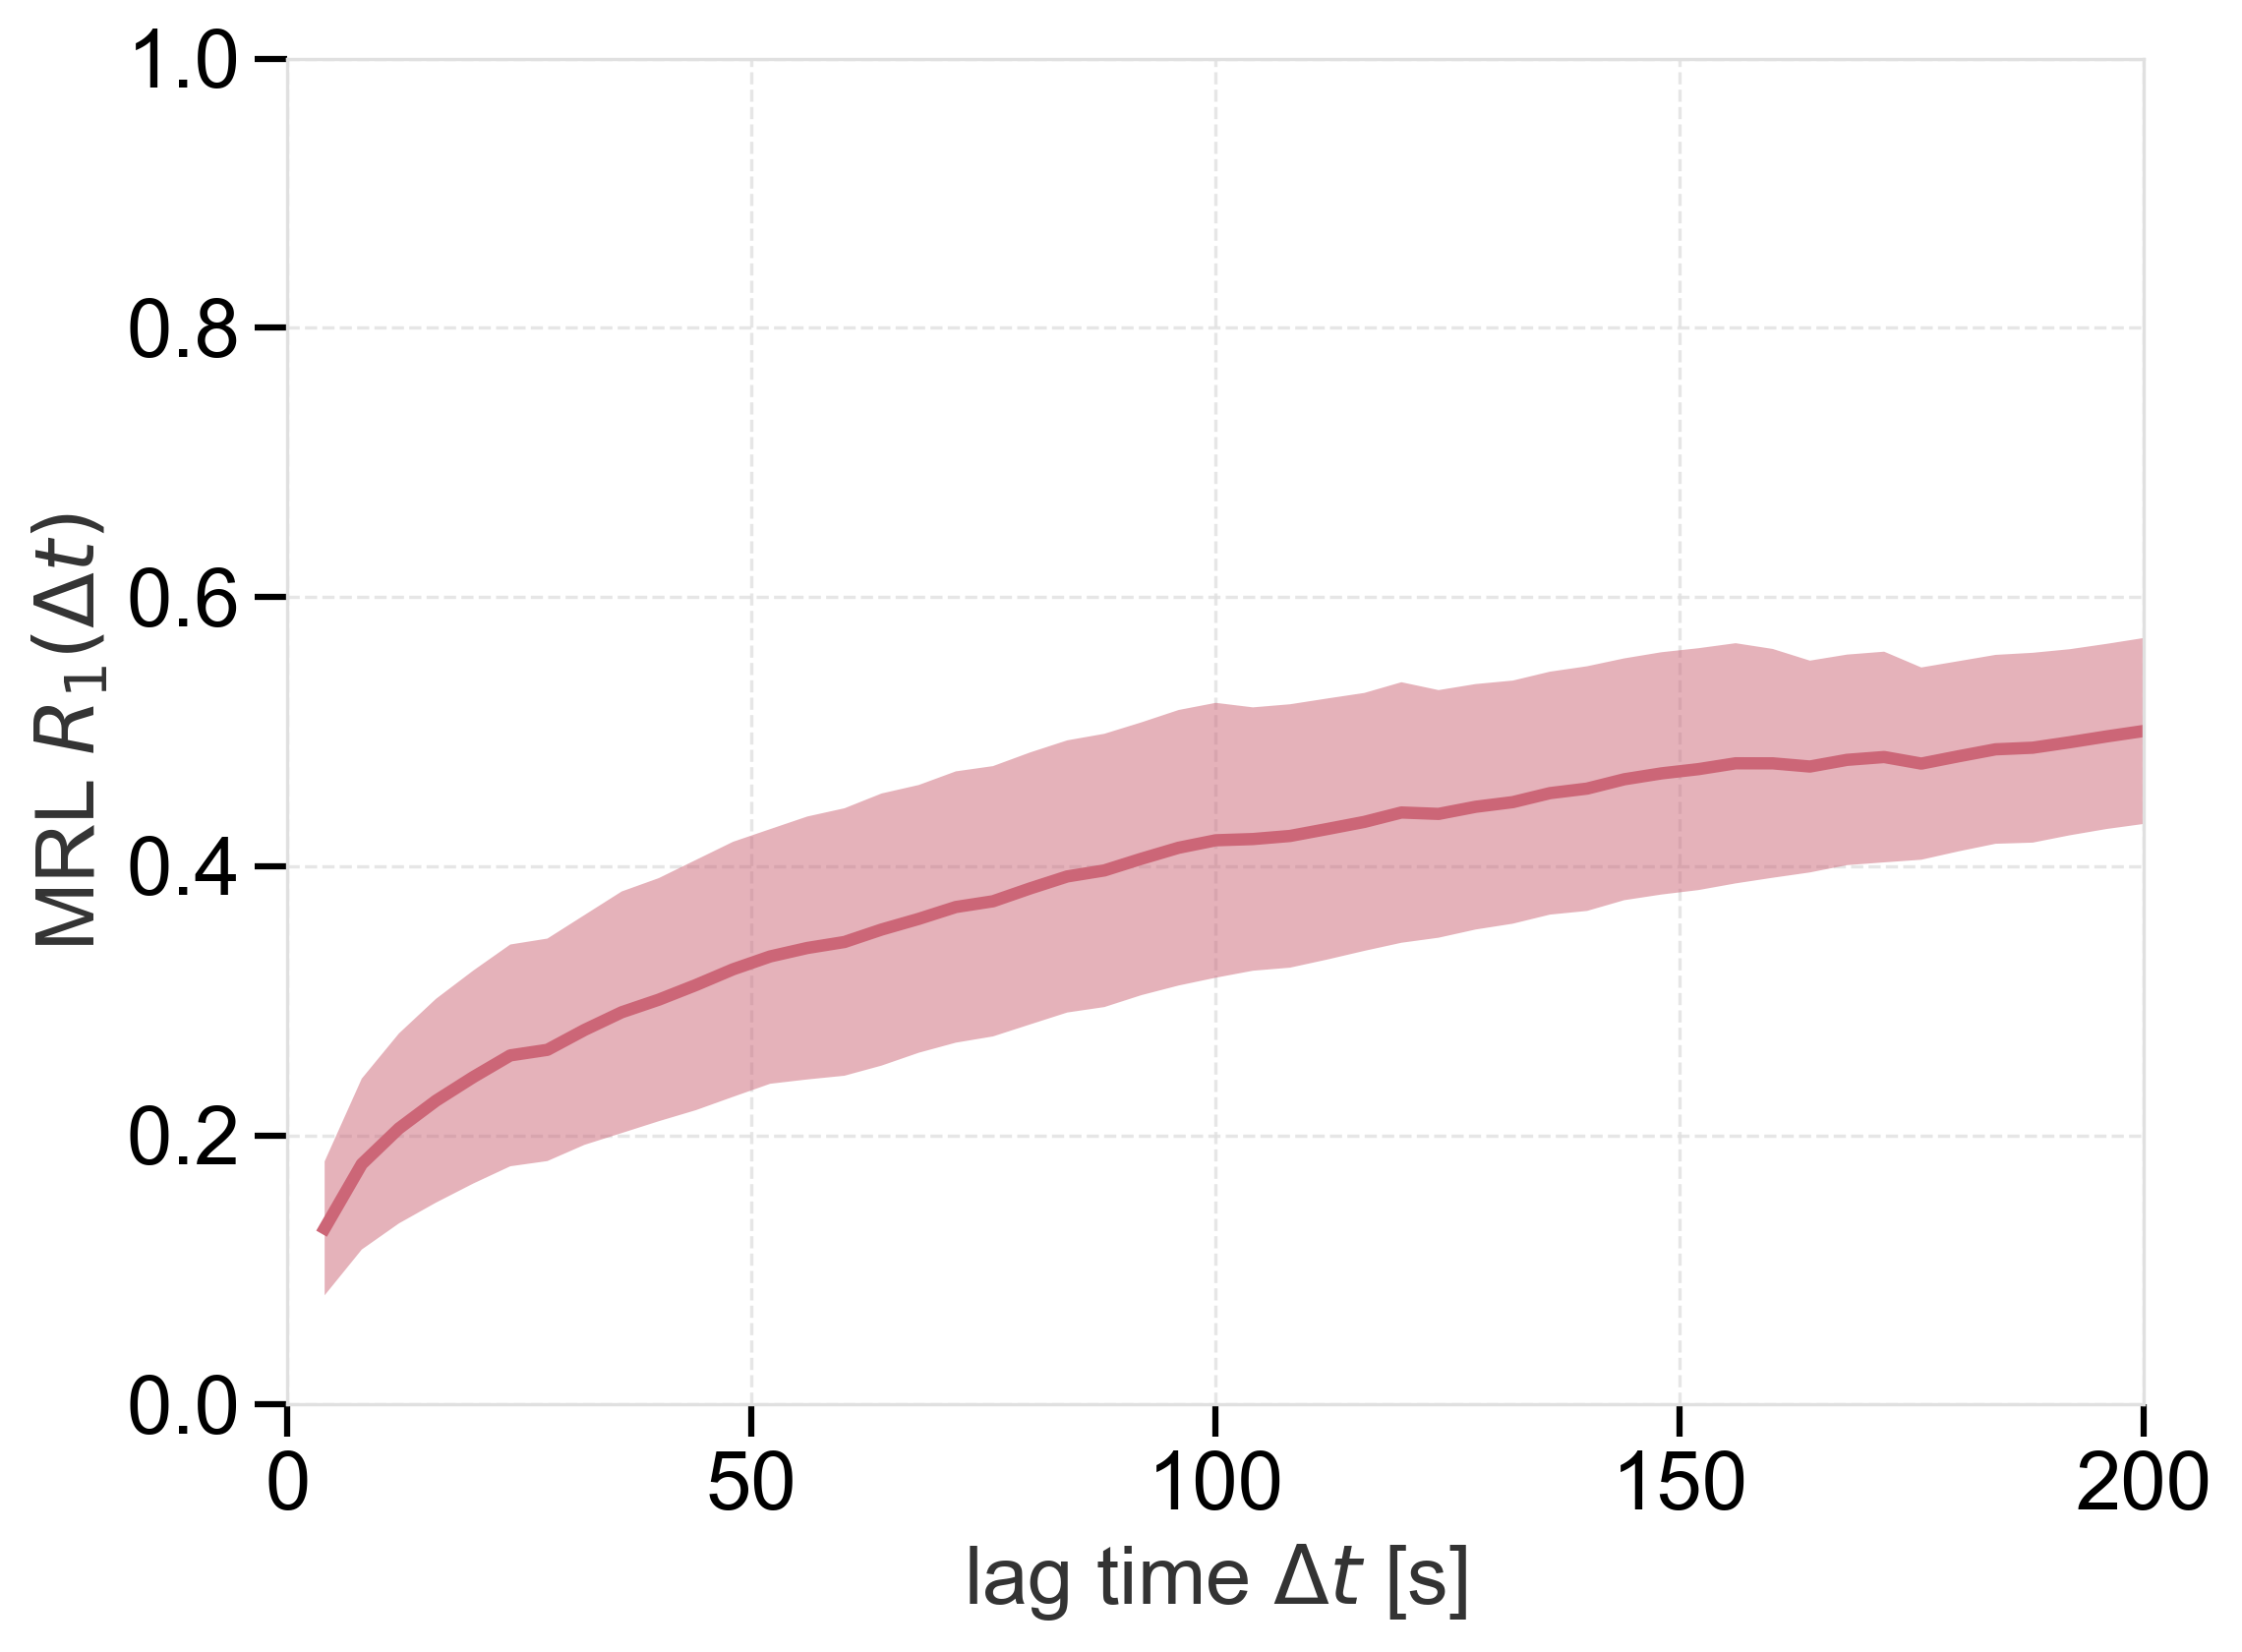

      lag  mrl2_axis  mrl2_strength  std_axis
0       4  -0.089026       0.120497  0.044512
1       8  -0.078449       0.135798  0.060044
2      12  -0.103631       0.136624  0.091345
3      16  -0.100348       0.160473  0.096553
4      20  -0.085187       0.149310  0.112350
..    ...        ...            ...       ...
995  3984        NaN            NaN       NaN
996  3988        NaN            NaN       NaN
997  3992        NaN            NaN       NaN
998  3996        NaN            NaN       NaN
999  4000        NaN            NaN       NaN

[1000 rows x 4 columns]


[(0.0, 200.0),
 (0.0, 1.0),
 None,
 None,
 Text(0.5, 0, 'lag time $\\Delta$ t [s]'),
 Text(0, 0.5, 'MRL')]

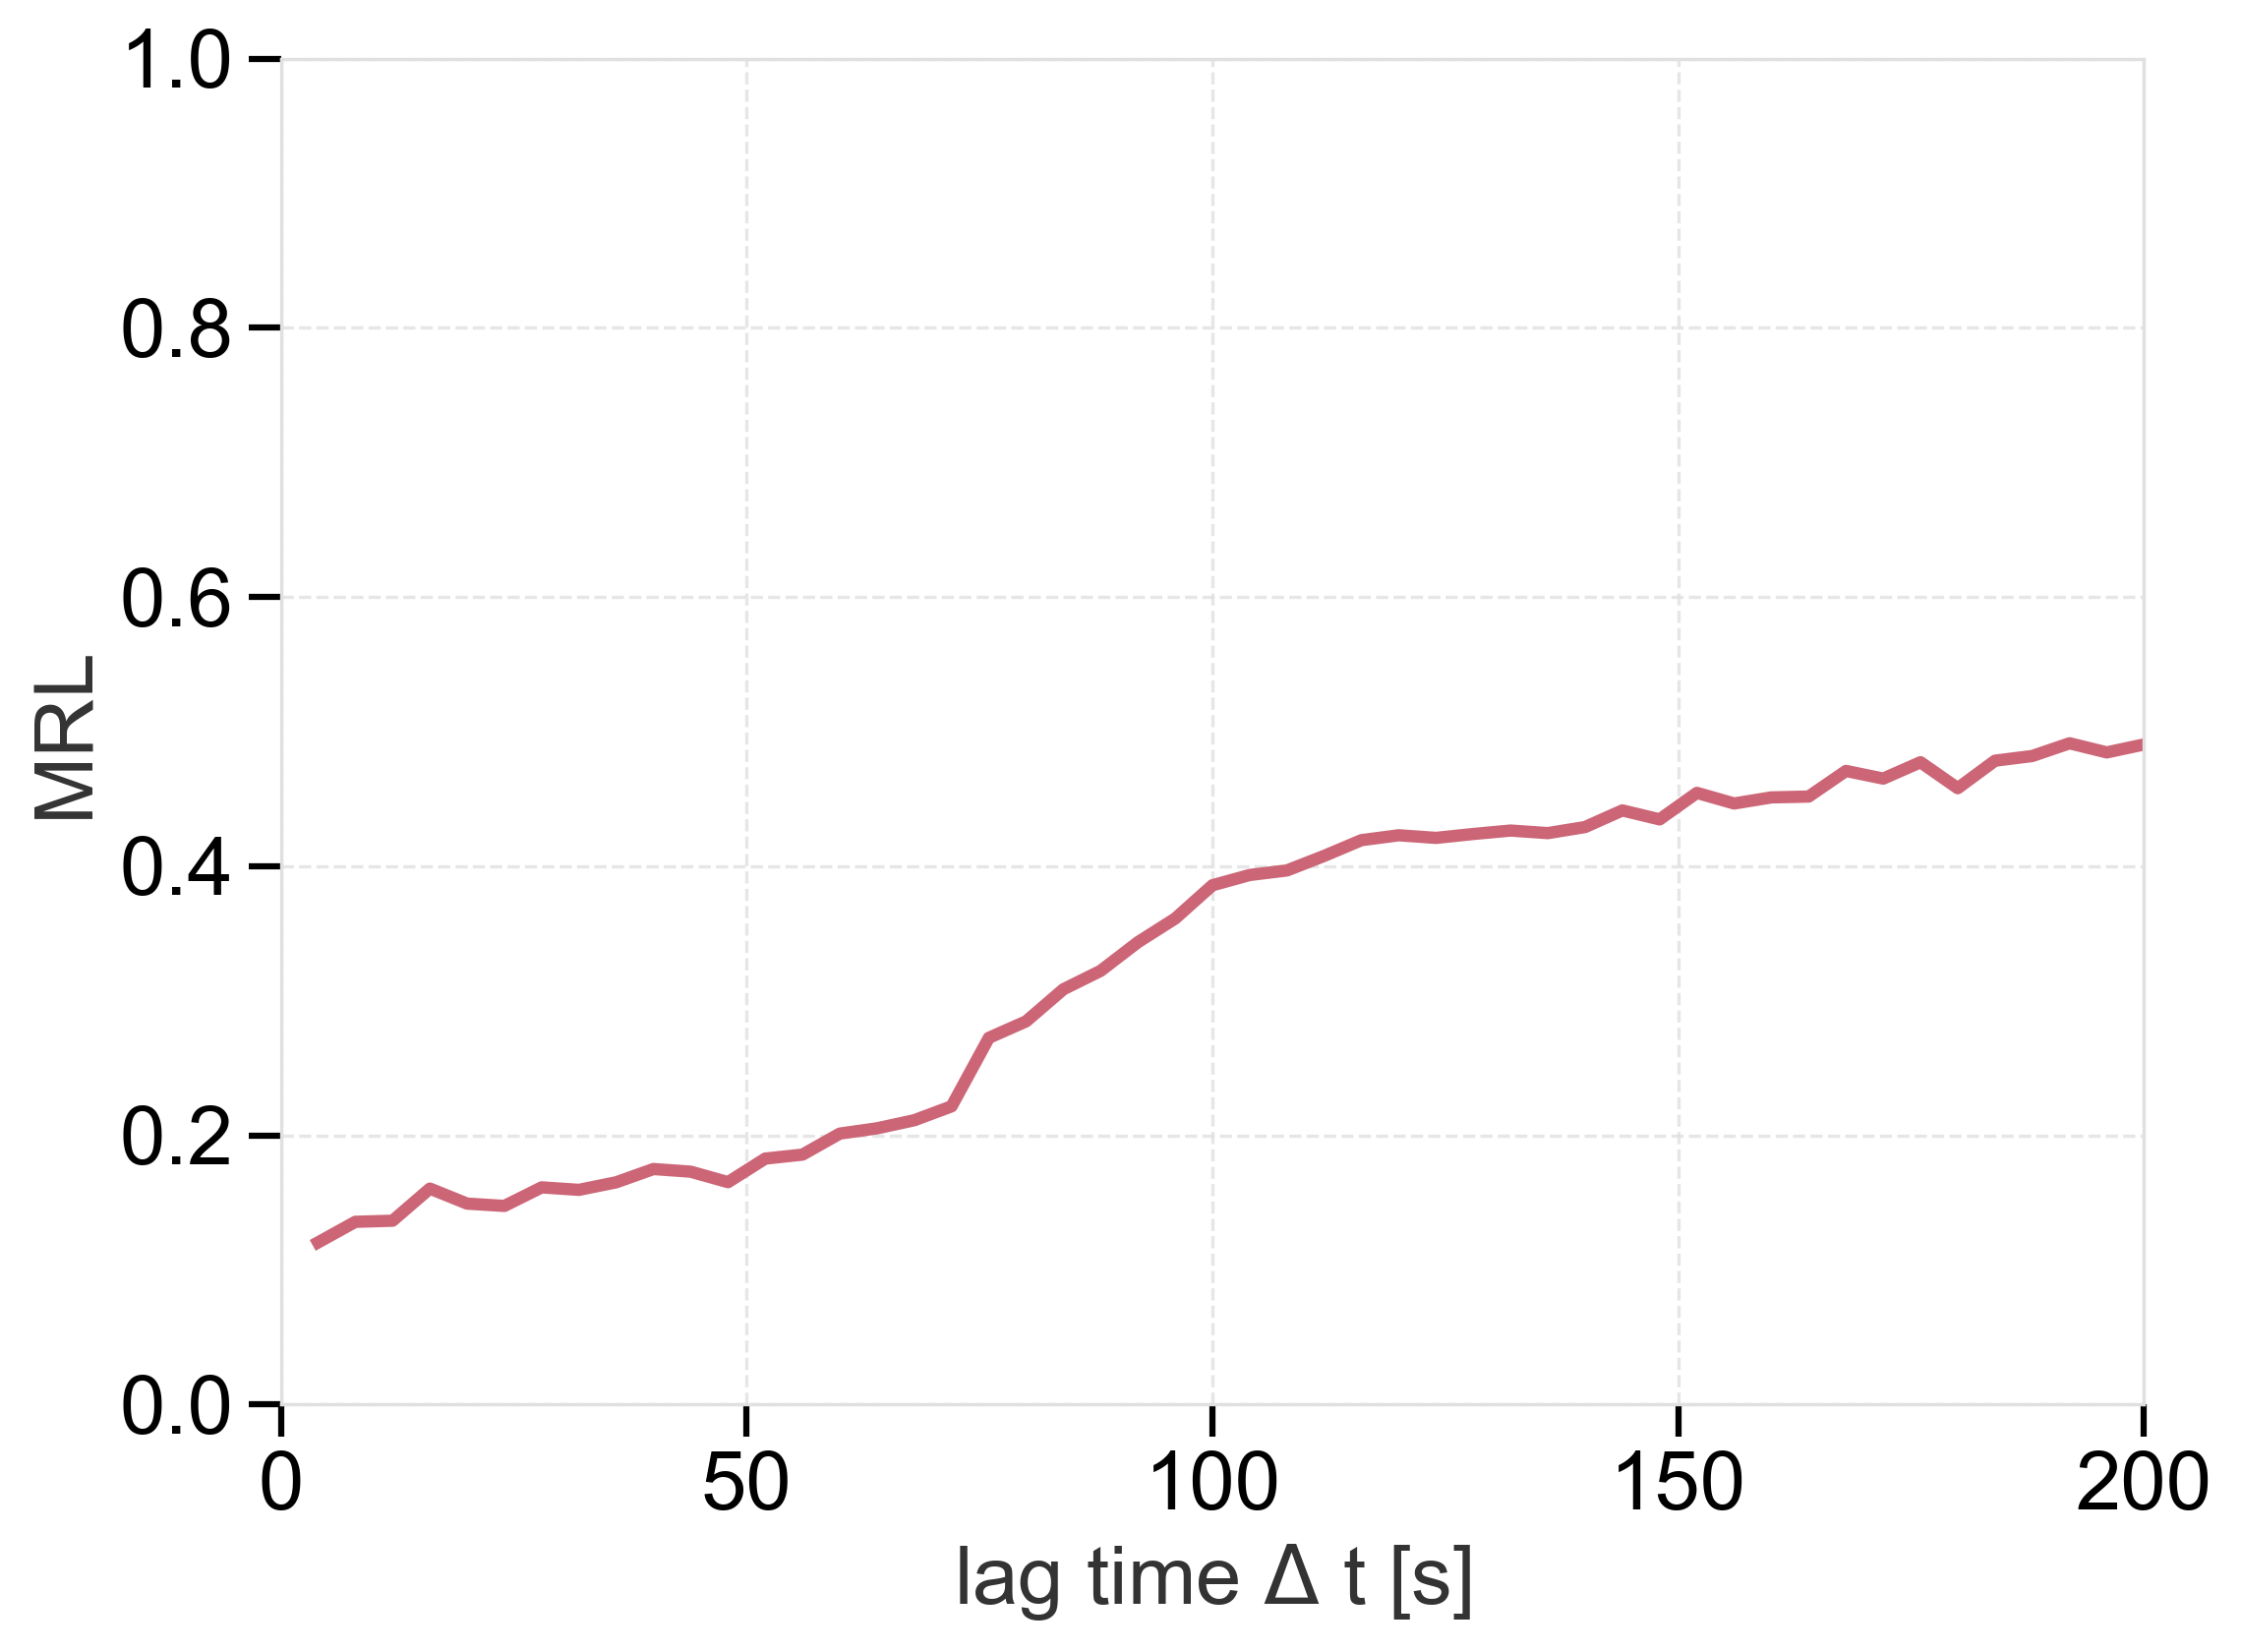

In [43]:
import numpy as np
import pandas as pd

def calcMRL2(df, max_lag, interval=1):
    results = []
    
    # 1. データのソート
    df = df.sort_values(['particle', 'frame'])
    
    for lag in range(1, max_lag + 1):
        g = df.groupby('particle')
        dx = g['x'].diff(periods=lag)
        dy = g['y'].diff(periods=lag)

        dr = np.sqrt(dx**2 + dy**2)
        
        # 移動があるデータのみ計算対象にする
        mask = dr > 0
        
        # 各ステップの単位ベクトル (cosθ, sinθ)
        u = dx[mask] / dr[mask]
        v = dy[mask] / dr[mask]
        
        # --- ここが重要：2倍角の成分を計算 ---
        # cos(2θ) = cos²θ - sin²θ = 2cos²θ - 1
        # sin(2θ) = 2sinθcosθ
        cos2theta = 2 * (u**2) - 1
        sin2theta = 2 * u * v
        
        temp_df = pd.DataFrame({
            'particle': df.loc[mask, 'particle'],
            'c2': cos2theta,
            's2': sin2theta
        })

        if temp_df.empty:
            results.append({'lag': lag * interval, 'mrl2_axis': np.nan, 'mrl2_strength': np.nan})
            continue

        # --- 2. 粒子ごとに平均をとる ---
        # 粒子内での「軸の定まり具合」を計算
        particle_stats = temp_df.groupby('particle').mean()
        C2 = particle_stats['c2']
        S2 = particle_stats['s2']
        
        # 粒子ごとの「軸方向の偏り（水平+1 vs 垂直-1）」
        # ※ C2だけで評価しても良いですが、厳密にはベクトル和の実部です
        axis_bias_per_particle = C2 
        
        # 粒子ごとの「偏りの強さ（0〜1）」
        strength_per_particle = np.sqrt(C2**2 + S2**2)
        
        # --- 3. 全粒子のアンサンブル平均 ---
        results.append({
            'lag': lag * interval,
            'mrl2_axis': axis_bias_per_particle.mean(),     # 軸の向き (+1:水平, -1:垂直)
            'mrl2_strength': strength_per_particle.mean(),  # 軸への集中度 (0:円, 1:直線)
            'std_axis': axis_bias_per_particle.std()
        })
    
    return pd.DataFrame(results)

# --- 実行 ---
# 例：ラグ1から20まで計算
max_lag = 1000
mrl2 = calcMRL2(df, max_lag, INTERVAL)

print(mrl2)

import matplotlib.pyplot as plt

fig, ax = plt.subplots()

ax.plot(mrl2['lag'], mrl2['mrl2_strength'])
#ax.fill_between(mrl2['lag'], mrl2['mrl'] + mrl2['std'], mrl2['mrl'] - mrl2['std'], alpha = 0.5)

ax.set(
    xlim=(0, 200),
    ylim=(0, 1),
    xscale='linear',
    yscale='linear',
    xlabel='lag time $\Delta$ t [s]',
    ylabel='MRL'
    )